Stopping search: maximum iterations reached --> 10

Best Parameters Found by PSO:
n_estimators: 238
max_depth: 7
learning_rate: 0.0226
subsample: 0.5742
colsample_bytree: 0.7530
Best RMSE: 41.6646

Model Evaluation on Test Data:
RMSE: 41.6646
MAE: 20.7441
R² Score: 0.8872


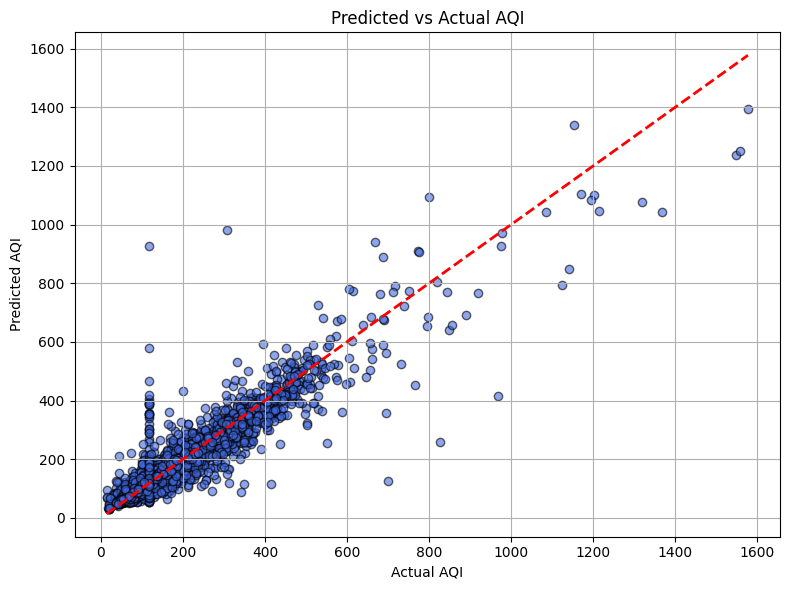

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from pyswarm import pso

# Load Dataset
df = pd.read_csv("./AirQuality_Cleaned.csv")

# Drop non-numeric or unnecessary columns
df = df.drop(columns=['Date'])

# Define Features and Target
X = df.drop(columns=['AQI', 'AQI_Bucket'])
y = df['AQI']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# PSO Objective Function: Minimize RMSE
def objective_function(params):
    n_estimators = int(params[0])
    max_depth = int(params[1])
    learning_rate = params[2]
    subsample = params[3]
    colsample_bytree = params[4]

    model = XGBRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        objective='reg:squarederror',
        n_jobs=-1,
        verbosity=0
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return rmse

# Bounds for PSO parameters
lb = [50, 3, 0.01, 0.5, 0.5]   # Lower bounds: n_estimators, max_depth, learning_rate, subsample, colsample_bytree
ub = [300, 10, 0.3, 1.0, 1.0]  # Upper bounds

# Run PSO
best_params, best_rmse = pso(objective_function, lb, ub, swarmsize=10, maxiter=10)

# Extract best parameters
n_estimators = int(best_params[0])
max_depth = int(best_params[1])
learning_rate = best_params[2]
subsample = best_params[3]
colsample_bytree = best_params[4]

print("\nBest Parameters Found by PSO:")
print(f"n_estimators: {n_estimators}")
print(f"max_depth: {max_depth}")
print(f"learning_rate: {learning_rate:.4f}")
print(f"subsample: {subsample:.4f}")
print(f"colsample_bytree: {colsample_bytree:.4f}")
print(f"Best RMSE: {best_rmse:.4f}")

# Train final model with best parameters
final_model = XGBRegressor(
    n_estimators=n_estimators,
    max_depth=max_depth,
    learning_rate=learning_rate,
    subsample=subsample,
    colsample_bytree=colsample_bytree,
    objective='reg:squarederror',
    n_jobs=-1,
    verbosity=0
)

final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

# Evaluation Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation on Test Data:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

import matplotlib.pyplot as plt

# Scatter plot of actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='royalblue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)  # Ideal line
plt.title('Predicted vs Actual AQI')
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.grid(True)
plt.tight_layout()
plt.show()
